# Signal to noise ratio
The signal to noise (SNR) ratio is a measure for the amount of noise in a measurement / recording. The underlying signal model is

$y(n) = x(n) + e(n)$

with $y(n)$ corresponding to the noisy measurement, $x(n)$ is the noise-free signal and $e(n)$ is the recorded noise.

The SNR is evaluated by the relationship between the signal energy and the noise energy:

$\text{SNR} = \frac{\sum_n x^2(n)}{\sum_n e^2(n)} = \frac{\sum_n x^2(n)}{\sum_n \left(x(n)-y(n)\right)^2}$

The SNR is typically measured in [Decibel](./Decibel.ipynb):

$\text{SNR} = 10\log_{10}\left(\frac{\sum_n x^2(n)}{\sum_n e^2(n)}\right) = 10\log_{10}\left(\frac{\sum_n x^2(n)}{\sum_n \left(x(n)-y(n)\right)^2}\right)$

In [4]:
import numpy as np

def SNR(x, y):
    return 10*np.log10(np.sum(x**2)/np.sum((x-y)**2))

x = np.random.randn(1000)
y = x + np.random.randn(x.shape[0])
assert np.abs(SNR(x, y)) < 0.5, 'SNR should be close to 0 for signal and noise having same power'
print('All tests passed successfully')

All tests passed successfully


In the following, a noiseless sinus is plotted in blue, a noisy sinus is plotted in red for different levels of background noise or different values of SNR.

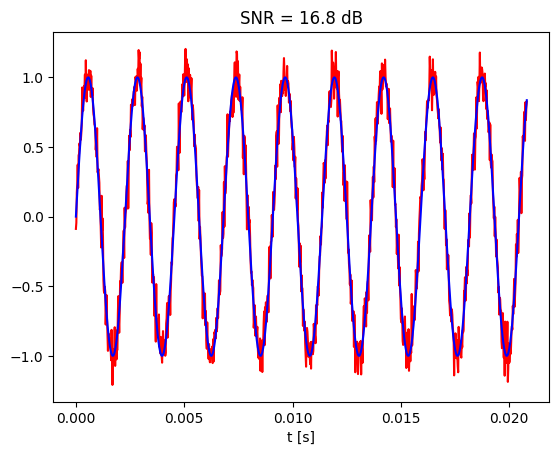

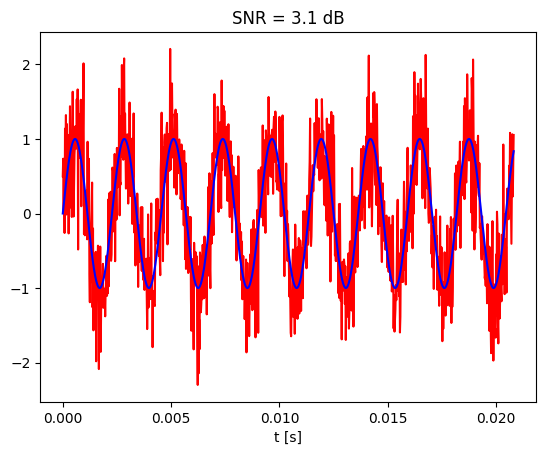

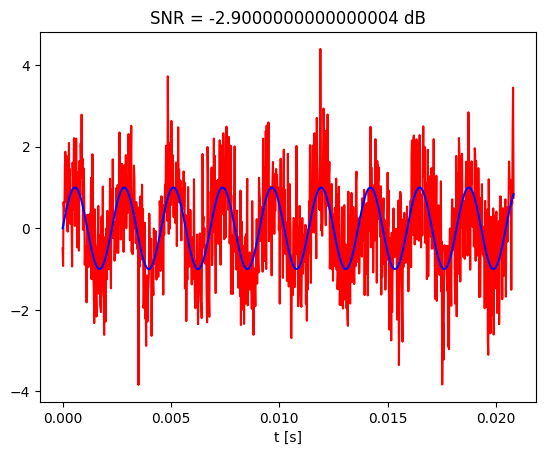

In [5]:
import matplotlib.pyplot as plt

SamplingRate = 48000
SignalFrequency = 440
t = np.arange(1000)/SamplingRate
x = np.sin(2*np.pi*SignalFrequency*t)
y1 = x + np.random.randn(x.shape[0])*0.1
y2 = x + np.random.randn(x.shape[0])*0.5
y3 = x + np.random.randn(x.shape[0])*1.0

def SNR(x, y):
    return 10*np.log10(np.sum(x**2)/np.sum((x-y)**2))

def CreateSinglePlot(x, y):
    plt.plot(t, y, 'r')
    plt.plot(t, x, 'b')
    plt.xlabel('t [s]')
    ATitle = 'SNR = ' + str(int(SNR(x, y)*10)*0.1) + ' dB'
    plt.title(ATitle)
    plt.show()

CreateSinglePlot(x, y1)
CreateSinglePlot(x, y2)
CreateSinglePlot(x, y3)